In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
df = pd.read_csv("assets/datasets/breast-cancer.csv")

In [ ]:
print("=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===")
vazios_por_coluna = df.isnull().sum()
print(vazios_por_coluna[vazios_por_coluna > 0]) 

if vazios_por_coluna.sum() == 0:
    print("Excelente! Nenhuma coluna possui dados em branco.")
else:
    print(f"\nTotal de células em branco no dataset: {vazios_por_coluna.sum()}")

print("\n" + "="*50 + "\n")

=== QUANTIDADE DE DADOS EM BRANCO POR COLUNA ===
Series([], dtype: int64)
Excelente! Nenhuma coluna possui dados em branco.




In [9]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

y = y.map({'M': 1, 'B': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [10]:
naive_bayes = GaussianNB()

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

naive_bayes.fit(X_train_scaled, y_train)

print("Modelo Naive Bayes treinado com sucesso!")

Modelo Naive Bayes treinado com sucesso!


In [11]:
y_pred = naive_bayes.predict(X_test_scaled)
y_probs = naive_bayes.predict_proba(X_test_scaled)[:, 1]

print("=== MATRIZ DE CONFUSÃO ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\n" + "="*30)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred, target_names=['Benigno (B)', 'Maligno (M)']))

=== MATRIZ DE CONFUSÃO ===
[[69  3]
 [ 6 36]]


=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

 Benigno (B)       0.92      0.96      0.94        72
 Maligno (M)       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



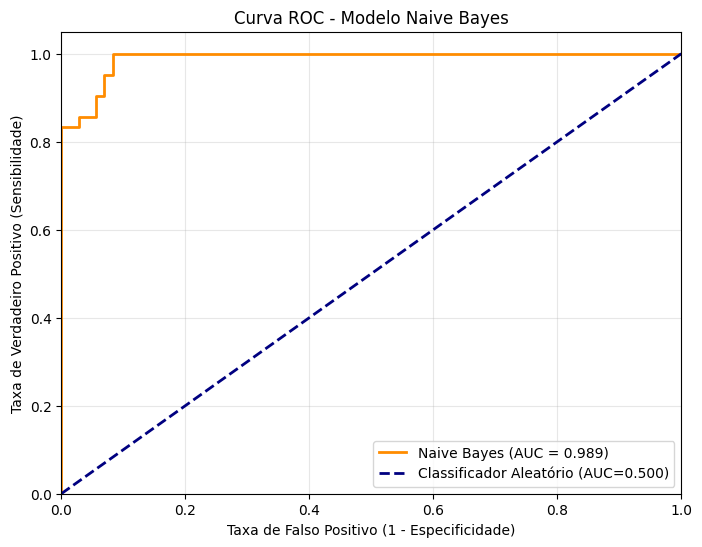

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Naive Bayes (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador Aleatório (AUC=0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)')
plt.title('Curva ROC - Modelo Naive Bayes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
analise_erros = X_test.copy()

analise_erros['Real'] = y_test.map({1: 'M', 0: 'B'})
analise_erros['Predito'] = y_pred
analise_erros['Predito'] = analise_erros['Predito'].map({1: 'M', 0: 'B'})
analise_erros['Prob_Maligno'] = y_probs

erros_do_modelo = analise_erros[analise_erros['Real'] != analise_erros['Predito']]

print(f"O modelo errou em {len(erros_do_modelo)} pacientes de 114.")
erros_do_modelo[['Real', 'Predito', 'Prob_Maligno']].head(10)

O modelo errou em 9 pacientes de 114.


,Real,Predito,Prob_Maligno
99,M,B,0.018347
318,B,M,0.951751
73,M,B,0.000008
86,M,B,0.010861
100,M,B,0.000253
505,B,M,0.858006
385,M,B,0.000011
128,B,M,0.999450
205,M,B,0.005916


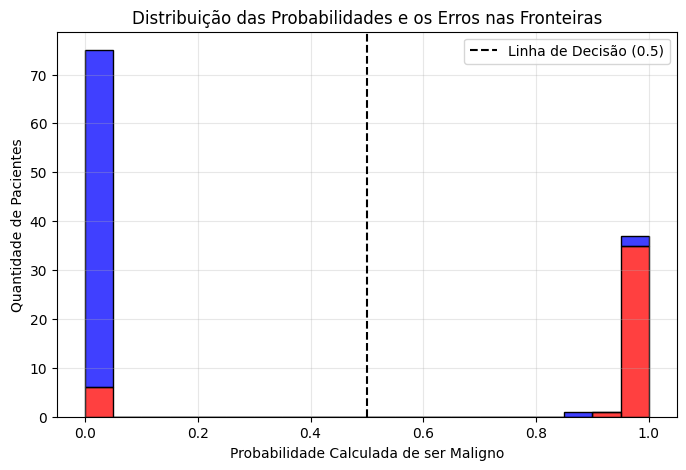

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(data=analise_erros, x='Prob_Maligno', hue='Real', bins=20, multiple='stack', palette=['blue', 'red'])
plt.axvline(0.5, color='black', linestyle='--', label='Linha de Decisão (0.5)')
plt.title('Distribuição das Probabilidades e os Erros nas Fronteiras')
plt.xlabel('Probabilidade Calculada de ser Maligno')
plt.ylabel('Quantidade de Pacientes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()